In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [11]:
data = load_breast_cancer ()

X = data.data
Y = data.target

print("Dataset Shape:",X.shape)
print("Classes:",np.unique(Y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [15]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
mle_model = LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42
)
mle_model.fit(X_train , Y_train)

Y_pred_mle = mle_model.predict(X_test)

In [29]:
map_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)
map_l2.fit(X_train,Y_train)
Y_pred_l2 = map_l2.predict(X_test)
    

In [31]:
map_l1 = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)
map_l1.fit(X_train,Y_train)
Y_pred_l1 = map_l1.predict(X_test)

In [36]:
def evaluate(model_name,Y_true,Y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy :",accuracy_score(Y_true, Y_pred))
    print("Precision :",precision_score(Y_true, Y_pred))
    print("Recall :",recall_score(Y_true, Y_pred))
    print("F1 Score :",f1_score(Y_true, Y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(Y_true , Y_pred))
    

In [41]:
evaluate ("MLE", Y_test , Y_pred_mle)

evaluate("MAP (L2)", Y_test, Y_pred_l2)

evaluate("MAP (L1)", Y_test,Y_pred_l1)


MLE
Accuracy : 0.9210526315789473
Precision : 0.9701492537313433
Recall : 0.9027777777777778
F1 Score : 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

MAP (L2)
Accuracy : 0.9824561403508771
Precision : 0.9861111111111112
Recall : 0.9861111111111112
F1 Score : 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]

MAP (L1)
Accuracy : 0.9912280701754386
Precision : 0.9863013698630136
Recall : 1.0
F1 Score : 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]


In [44]:
print("Number of Zero Coefficents")
print("MLE :",np.sum(mle_model.coef_[0]==0))
print("MAP L2 :",np.sum(map_l2.coef_[0]==0))
print("MAP L1 :",np.sum(map_l1.coef_[0]==0))


Number of Zero Coefficents
MLE : 0
MAP L2 : 0
MAP L1 : 14


In [52]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])
models=[
    ("MLE",mle_model,Y_pred_mle),
    ("MAP L2",map_l2, Y_pred_l2),
    ("MAP L1",map_l1, Y_pred_l1),
]
for name,model,pred in models:
    results.loc[len(results)] = [
        name,
        accuracy_score(Y_test , pred),
        precision_score(Y_test , pred),
        recall_score(Y_test , pred),
        f1_score(Y_test , pred)
    ]
print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


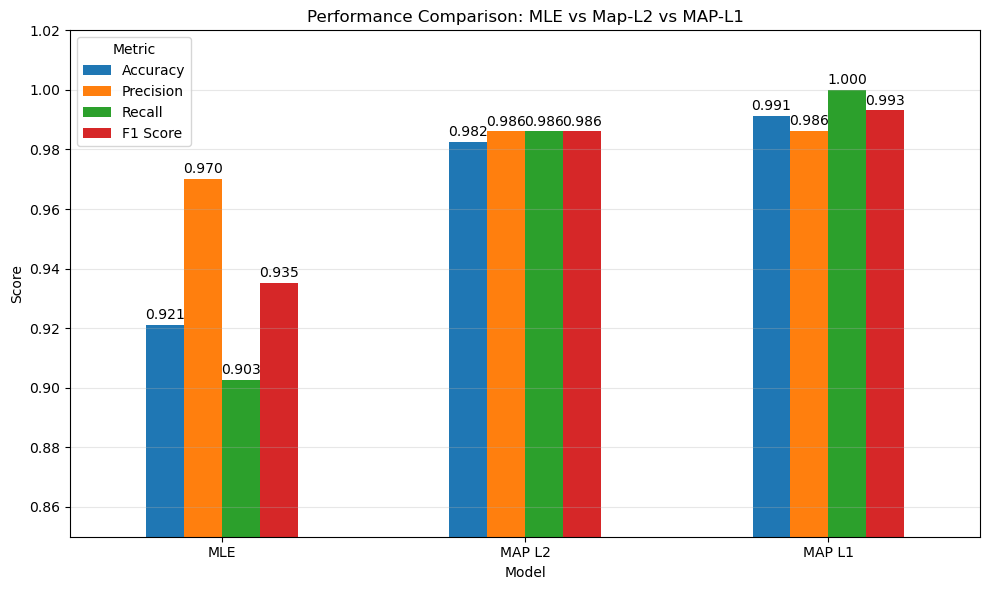

In [62]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Performance Comparison: MLE vs Map-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)

for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)

plt.tight_layout()
plt.show()


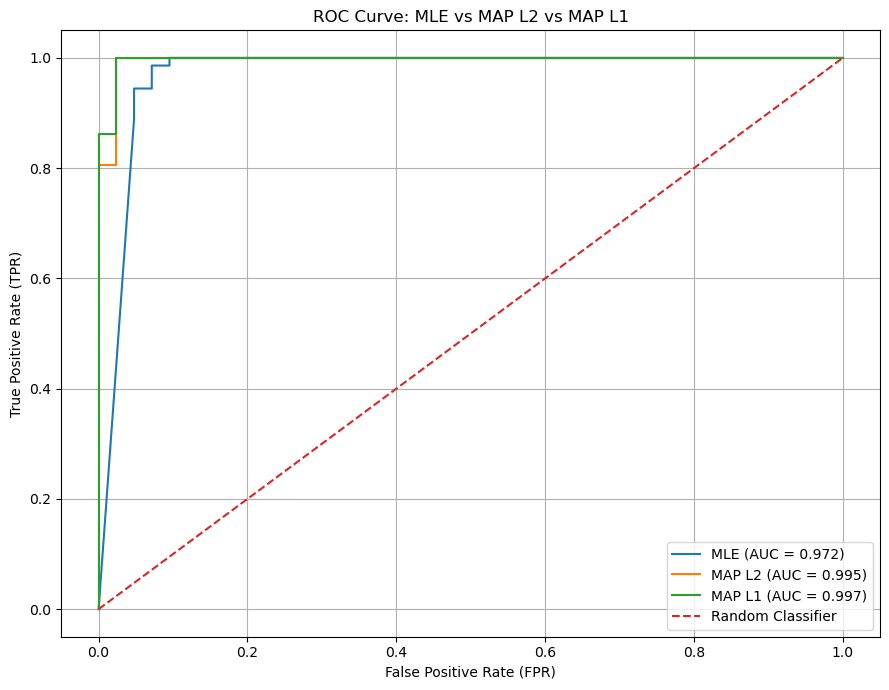

In [65]:
plt.figure(figsize=(9,7))

for name,model, pred in models:

    #Predicted probability for positive class
    Y_prob = model.predict_proba(X_test)[:,1]

    #Calculate ROC values
    fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

    #Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
)

#Random classsifier reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

#Zoom into the useful region
#plt.xlim(0,0.15)
#plt.ylim(0.75,1.01)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

